In [2]:
from pathlib import Path
import sys

# Make repo root importable (so `import main` works)
repo_root = Path.cwd().parent  # notebook dir -> project root
sys.path.insert(0, str(repo_root))

from main import reimport
import warnings
warnings.filterwarnings('ignore')

from Steady_state_equilibrium.SS_Solver import SteadyStateEquilibrium

import numpy as np
import pandas as pd
import scipy.interpolate as si
from matplotlib import pyplot as plt

## Демография

In [3]:
omega = pd.read_excel(
    '/home/eurapartners.local/moiseev.kv/Repositories/Cost_of_ageing/Data/total_pop.xlsx'
) # in thousands

omega.set_index('Year', inplace=True)
omega /= 1000 # now in mils
omega.head()

,0,1,2,3,4,5,6,7,8,9,...,91,92,93,94,95,96,97,98,99,100
Year,,,,,,,,,,,,,,,,,,,,,
2024,1.277417,1.312895,1.380561,1.446116,1.487208,1.567881,1.670708,1.810267,1.930952,1.949820,...,0.140585,0.126703,0.107781,0.087376,0.066252,0.048631,0.032987,0.021349,0.013078,0.016232
2025,1.246285,1.271581,1.308049,1.376177,1.442105,1.483526,1.564484,1.667557,1.807322,1.928187,...,0.127439,0.115805,0.102549,0.085620,0.068076,0.050547,0.036274,0.024023,0.015157,0.020228
2026,1.224295,1.246173,1.271931,1.308417,1.376515,1.442405,1.483793,1.564708,1.667729,1.807435,...,0.148059,0.105124,0.093856,0.081592,0.066803,0.052020,0.037760,0.026459,0.017086,0.024442
2027,1.210562,1.230467,1.252234,1.277520,1.313540,1.381201,1.446697,1.487726,1.568304,1.671013,...,0.177382,0.122317,0.085336,0.074790,0.063772,0.051130,0.038931,0.027589,0.018855,0.028696
2028,1.199379,1.216619,1.236402,1.257707,1.282536,1.318133,1.385408,1.450549,1.491254,1.571531,...,0.212148,0.146734,0.099436,0.068107,0.058541,0.048891,0.038321,0.028490,0.019689,0.032850


In [4]:
def get_mort(totpers, graph=False):
    data = pd.read_excel('/home/eurapartners.local/moiseev.kv/Repositories/Cost_of_ageing/Data/death_probability.xlsx')
    data.set_index('Year', inplace=True)
    mort = pd.DataFrame(index=data.index, columns=np.arange(totpers)+1)
    for i, year in enumerate(data.index):
        mort_data = data.iloc[i, :]
        mort_data.loc[-1] = 0.
        mort_data.loc[-2] = 0.
        mort_data.loc[101] = 1.
        mort_data.loc[102] = 1.

        age_midp = mort_data.index.values

        fit_mort = si.interp1d(age_midp, mort_data, kind='cubic', bounds_error=False, fill_value=0)

        age_model = np.linspace(100 / totpers, 100, totpers) - (0.5 * 100 / totpers)
        mort_model = fit_mort(age_model)
        fit = fit_mort(np.linspace(0, 100, 1000))

        mort.loc[year] = mort_model
    return mort[(mort >= 0.)&(mort <= 1.)].ffill(axis=1)

In [5]:
rho = get_mort(100)
rho.head()

,1,2,3,4,5,6,7,8,9,10,...,91,92,93,94,95,96,97,98,99,100
Year,,,,,,,,,,,,,,,,,,,,,
2024,0.003242,0.003242,0.003242,0.003242,0.000187,0.001342,0.001802,0.001770,0.001474,0.001144,...,0.653907,0.677657,0.702053,0.730243,0.765375,0.810375,0.863029,0.915987,0.961673,0.992514
2025,0.003108,0.003108,0.003108,0.003108,0.000189,0.001294,0.001734,0.001704,0.001422,0.001110,...,0.651599,0.675440,0.699936,0.728264,0.763605,0.808912,0.861955,0.915320,0.961366,0.992454
2026,0.002977,0.002977,0.002977,0.002977,0.000191,0.001247,0.001667,0.001639,0.001371,0.001076,...,0.648988,0.672903,0.697487,0.725956,0.761526,0.807187,0.860685,0.914530,0.961002,0.992382
2027,0.002857,0.002857,0.002857,0.002857,0.000192,0.001203,0.001606,0.001580,0.001325,0.001044,...,0.646180,0.670175,0.694863,0.723496,0.759323,0.805366,0.859348,0.913700,0.960620,0.992307
2028,0.002736,0.002736,0.002736,0.002736,0.000193,0.001159,0.001544,0.001519,0.001277,0.001011,...,0.643941,0.668056,0.692899,0.721729,0.757805,0.804153,0.858480,0.913171,0.960380,0.992260


<BarContainer object of 101 artists>

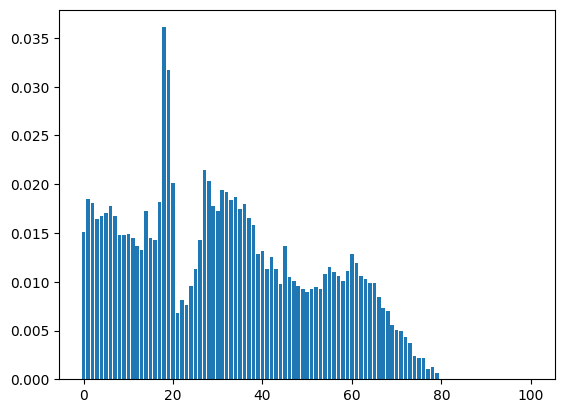

In [6]:
I = pd.read_excel('/home/eurapartners.local/moiseev.kv/Repositories/Cost_of_ageing/Data/age specific migration.xlsx',
                     sheet_name='migration').set_index('Year') # in thousands
I /= 1000 # now in mils
i = pd.read_excel('/home/eurapartners.local/moiseev.kv/Repositories/Cost_of_ageing/Data/age specific migration.xlsx',
                     sheet_name='rate').set_index('age')
i = i['average']
plt.bar(i.index, i)

## Rest of params


The initial steady state is in the year $2025$, the resulting steady state is in the year $2100$.

In [7]:
g_n = omega.loc[2025].sum() / omega.loc[2024].sum() - 1
params = {
    'A': 1.,
    'alpha': .35,
    'delta': .05,
    'tau_c': 0.,
    'tau_l': .3,
    'tau_k': 0.,
    'R': 65,
    'E': 20,
    'S': 100,
    'g_n': g_n,
    'g_y': .03,
    'beta': .96,
    'sigma': 2.2,
    'replacement_rate': .25,
    'ltilde': 1.,
    'b_ellip': .4309,
    'upsilon': 1.7648,
}
# Normalizing population to 1 for convenience
pop_base = omega.sum(axis=1)
omega_norm = omega.div(pop_base, axis=0)
I_norm = I.div(pop_base, axis=0)

vectors = {
    'omega': omega_norm.loc[2025][:-1].values,
    'rho': rho.loc[2025].values,
    'i_rate': i[:-1].values,
    'I_total': I_norm.loc[2025].values,
}

In [8]:
reimport()

steady_state = SteadyStateEquilibrium(params, vectors)
ss_results = steady_state.solve(
    r_guess=0.2,
    BQ_guess=0.2,
    tax_guess=0.1,
    policy_mode='fix_pension',
    tax_type='tau_l',
    xi = 0.2,
    tol = 1e-5,
    max_iter = 300,
    debug = True
)

Starting Steady State Solver (Mode: fix_pension, Tax: tau_l)...
Iter 0: Error=0.200000 | r=0.2000 | BQ=0.2000 | PolVar=0.1000
Iter 10: Error=0.088843 | r=0.2075 | BQ=0.0259 | PolVar=0.0755
Iter 20: Error=0.060018 | r=0.2039 | BQ=0.0028 | PolVar=0.0697
Iter 30: Error=0.050374 | r=0.2026 | BQ=0.0003 | PolVar=0.0685
Iter 40: Error=0.046799 | r=0.2021 | BQ=0.0000 | PolVar=0.0682
Iter 50: Error=0.045331 | r=0.2019 | BQ=0.0000 | PolVar=0.0682
Iter 60: Error=0.044688 | r=0.2019 | BQ=0.0000 | PolVar=0.0681
Iter 70: Error=0.044396 | r=0.2018 | BQ=0.0000 | PolVar=0.0681
Iter 80: Error=0.044261 | r=0.2018 | BQ=0.0000 | PolVar=0.0681
Iter 90: Error=0.044198 | r=0.2018 | BQ=0.0000 | PolVar=0.0681
Iter 100: Error=0.044168 | r=0.2018 | BQ=0.0000 | PolVar=0.0681
Iter 110: Error=0.044154 | r=0.2018 | BQ=0.0000 | PolVar=0.0681
Iter 120: Error=0.044148 | r=0.2018 | BQ=0.0000 | PolVar=0.0681
Iter 130: Error=0.044145 | r=0.2018 | BQ=0.0000 | PolVar=0.0681
Iter 140: Error=0.044143 | r=0.2018 | BQ=0.0000 | P

[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  1.34741792e-01  2.72597968e-01  4.13471496e-01
  5.57209481e-01  7.03599824e-01  8.52368956e-01  1.00318104e+00
  1.15563674e+00  1.30927118e+00  1.46355364e+00  1.61788958e+00
  1.77162572e+00  1.92405553e+00  2.07442459e+00  2.22193842e+00
  2.36577301e+00  2.50508773e+00  2.63903012e+00  2.76672814e+00
  2.88727586e+00  2.99971126e+00  3.10298618e+00  3.19595240e+00
  3.27737201e+00  3.34593341e+00  3.40027265e+00  3.43900011e+00
  3.46072399e+00  3.46406857e+00  3.44769360e+00  3.41031530e+00
  3.35072790e+00  3.26780738e+00  3.16049280e+00  3.02775969e+00
  2.86858548e+00  2.68190777e+00  2.46660017e+00  2.22146900e+00
  1.94524836e+00  1.63659

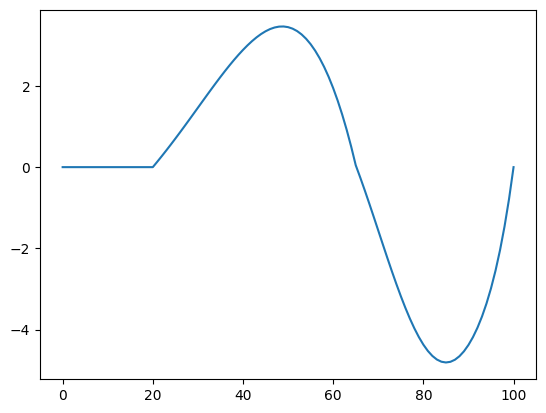

In [9]:
plt.plot(ss_results['b_vec'])
print(ss_results['b_vec'])

In [97]:
ss_results

{'r': 0.23710000669630127,
 'w': 0.7911871653966441,
 'BQ': 1e-09,
 'X_val': 0.19779679134916103,
 'tau_l': 0.0685333779070493,
 'tau_k': 0.0,
 'tau_c': 0.0,
 'Y': 0.7436552984750328,
 'K': 0.9065808024922442,
 'L': 0.6684135162655419,
 'C': 0.722869877852825,
 'c_vec': array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        5.89939799e-01, 6.07348338e-01, 6.25175591e-01, 6.43437622e-01,
        6.62142620e-01, 6.81289650e-01, 7.00867421e-01, 7.20855294e-01,
        7.41224627e-01, 7.61938017e-01, 7.82948419e-01, 8.04198364e-01,
        8.25621894e-01, 8.47146979e-01, 8.68695577e-01, 8.90183650e-01,
        9.11521599e-01, 9.32622654e-01, 9.53412532e-01, 9.73832081e-01,
        9.